In [1]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00


# S15 – Сравнение zero-shot, few-shot и LoRA-адаптации

В этом ноутбуке закрываем 15-й семинар целостной инженерной картиной:  
сравниваем три способа решения одной и той же задачи текстовой классификации с помощью LLM:

1. **zero-shot prompting** – даём только инструкцию без примеров;
2. **few-shot prompting** – добавляем несколько размеченных примеров прямо в prompt;
3. **LoRA-адаптация** – компактно дообучаем instruct-LLM под наш учебный домен.

Главная идея ноутбука не в том, чтобы «получить максимальную метрику любой ценой»,  
а в том, чтобы понять **когда достаточно prompt engineering**, а **когда уже нужна адаптация модели**.

Как и в двух предыдущих ноутбуках, используем **небольшую instruct-модель**,  
**короткие пользовательские сообщения** и **компактный размеченный набор**.  
Так легче увидеть саму логику сравнения и не утонуть в инфраструктуре.


## 0. План

К концу ноутбука надо уметь:

1. Подготовить единый набор данных для сравнения zero-shot, few-shot и LoRA.
2. Запустить **один и тот же eval-loop** для нескольких подходов.
3. Сравнить методы по `accuracy`, `macro F1` и доле корректно распарсенных ответов.
4. Понять, где few-shot уже помогает, а где LoRA даёт дополнительный выигрыш.
5. Увидеть не только итоговые метрики, но и **структуру ошибок**.
6. Сделать инженерный вывод: что выбрать в реальном проекте при разных ограничениях.


## 1. Импорты и общие настройки

Ниже подключаем библиотеки, фиксируем `seed`, определяем устройство и настраиваем вывод.

Как и раньше, предусмотрен **опциональный 4-bit режим** через `bitsandbytes`, если есть GPU.  
Для сравнения подходов это удобно: можно держать одну и ту же базовую модель и при необходимости
загружать LoRA-адаптер поверх неё.

> Предполагается, что в окружении уже доступны `torch`, `transformers`, `datasets`, `peft`, `accelerate`, `scikit-learn`, `pandas`, `numpy` и `matplotlib`.  
> Пакет `bitsandbytes` желателен, но не обязателен.


In [2]:
# Базовые библиотеки для воспроизводимости, таблиц и сравнения нескольких подходов.
import os
import random
import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    default_data_collator,
)

from peft import LoraConfig, TaskType, get_peft_model, PeftModel

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    import bitsandbytes  # noqa: F401  – проверяем, что пакет реально установлен
    from transformers import BitsAndBytesConfig
    BNB_AVAILABLE = True
except Exception:
    BitsAndBytesConfig = None
    BNB_AVAILABLE = False

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("bitsandbytes config available:", BNB_AVAILABLE)


Torch: 2.10.0+cu128
CUDA available: True
bitsandbytes config available: True


In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)


Устройство: cuda


## 2. Контрольный набор текстов и сравниваемые подходы

Как и в S15-demo-01 и S15-demo-02, используем 4 класса:

- `bug` – ошибка, сбой, падение, некорректная работа;
- `feature` – просьба добавить функцию или улучшение;
- `question` – вопрос, уточнение, запрос информации;
- `praise` – положительный отзыв без просьбы что-то изменить.

Нам нужен **небольшой, но разнообразный набор** коротких пользовательских сообщений.  
Часть пойдёт в `train / validation` для LoRA, а `test` будем использовать как **общий контрольный набор**
для всех трёх подходов.


In [4]:
ALLOWED_LABELS = ["bug", "feature", "question", "praise"]

label_descriptions = {
    "bug": "сообщение об ошибке, падении, зависании, некорректной работе или явной проблеме",
    "feature": "предложение добавить функцию, фильтр, настройку или улучшить поведение",
    "question": "вопрос, уточнение, просьба объяснить или запрос информации",
    "praise": "положительный отзыв или благодарность без запроса на изменение",
}

samples: List[Dict[str, str]] = [
    # bug
    {"text": "После входа в аккаунт приложение закрывается без сообщения об ошибке.", "label": "bug"},
    {"text": "После последнего обновления фильтр по дате перестал применяться.", "label": "bug"},
    {"text": "При экспорте отчёта в PDF получаю пустой файл.", "label": "bug"},
    {"text": "Иногда страница аналитики открывается белым экраном.", "label": "bug"},
    {"text": "Новая версия формы оплаты зависает после нажатия на кнопку подтверждения.", "label": "bug"},
    {"text": "После смены пароля не удаётся снова войти, хотя данные верные.", "label": "bug"},
    {"text": "В мобильной версии карточка заказа иногда дублируется два раза.", "label": "bug"},
    {"text": "После обновления не сохраняются изменения профиля пользователя.", "label": "bug"},

    # feature
    {"text": "Было бы удобно добавить тёмную тему для панели управления.", "label": "feature"},
    {"text": "Сделайте, пожалуйста, фильтр по ответственному сотруднику.", "label": "feature"},
    {"text": "Хотелось бы экспортировать таблицу сразу в Excel, а не только в CSV.", "label": "feature"},
    {"text": "Добавьте горячие клавиши для переключения между разделами.", "label": "feature"},
    {"text": "Было бы полезно скрывать завершённые задачи из общего списка.", "label": "feature"},
    {"text": "Нужна возможность массово менять статусы выбранных объектов.", "label": "feature"},
    {"text": "Добавьте настройку частоты email-уведомлений.", "label": "feature"},
    {"text": "Сделайте отдельный режим просмотра только для чтения.", "label": "feature"},

    # question
    {"text": "Подскажите, где в системе можно скачать закрывающие документы?", "label": "question"},
    {"text": "Есть ли ограничение на количество пользователей в одной группе?", "label": "question"},
    {"text": "Как посмотреть историю изменений по карточке проекта?", "label": "question"},
    {"text": "Можно ли подключить вход через корпоративный SSO?", "label": "question"},
    {"text": "Где меняется язык интерфейса после первого входа?", "label": "question"},
    {"text": "Какой формат файлов поддерживается при импорте справочника?", "label": "question"},
    {"text": "Есть ли API для выгрузки результатов по всем подразделениям?", "label": "question"},
    {"text": "Подскажите, кто может назначать роли внутри рабочей области?", "label": "question"},

    # praise
    {"text": "Спасибо, новый интерфейс стал заметно понятнее и чище.", "label": "praise"},
    {"text": "Отличная работа, отчёты теперь формируются намного быстрее.", "label": "praise"},
    {"text": "Очень понравилось, что поиск стал находить нужные записи с первого раза.", "label": "praise"},
    {"text": "Спасибо команде, навигация по разделам стала гораздо удобнее.", "label": "praise"},
    {"text": "Классное обновление, наконец-то всё выглядит аккуратно и логично.", "label": "praise"},
    {"text": "Отдельное спасибо за понятные подсказки в форме создания заявки.", "label": "praise"},
    {"text": "Радует, что сервис стал работать стабильно даже на больших объёмах данных.", "label": "praise"},
    {"text": "Хорошее решение, теперь намного проще объяснять систему новым сотрудникам.", "label": "praise"},
]

df = pd.DataFrame(samples)
print("Всего примеров:", len(df))
display(df.head(8))
print("\nРаспределение классов:")
display(df["label"].value_counts())


Всего примеров: 32


,text,label
0,После входа в аккаунт приложение закрывается без сообщения об ошибке.,bug
1,После последнего обновления фильтр по дате перестал применяться.,bug
2,При экспорте отчёта в PDF получаю пустой файл.,bug
3,Иногда страница аналитики открывается белым экраном.,bug
4,Новая версия формы оплаты зависает после нажатия на кнопку подтверждения.,bug
5,"После смены пароля не удаётся снова войти, хотя данные верные.",bug
6,В мобильной версии карточка заказа иногда дублируется два раза.,bug
7,После обновления не сохраняются изменения профиля пользователя.,bug



Распределение классов:


,count
label,
bug,8
feature,8
question,8
praise,8


In [5]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.25,
    random_state=42,
    stratify=df["label"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,  # 0.25 от 75% = 18.75% от исходного набора
    random_state=42,
    stratify=train_val_df["label"],
)

print("Размеры выборок:")
print("train:", len(train_df))
print("validation:", len(val_df))
print("test:", len(test_df))

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())


Размеры выборок:
train: 18
validation: 6
test: 8

Распределение классов в train:


,count
label,
question,5
feature,5
bug,4
praise,4


Распределение классов в validation:


,count
label,
praise,2
bug,2
feature,1
question,1


Распределение классов в test:


,count
label,
bug,2
question,2
feature,2
praise,2


## 3. Общие prompt-шаблоны и служебные функции

Чтобы сравнение было корректным, используем **одну и ту же формулировку задачи**  
для zero-shot, few-shot и LoRA.

Это важно: если менять одновременно и модель, и шаблон, потом трудно понять,  
за счёт чего именно возникло улучшение.


In [6]:
SYSTEM_PROMPT = (
    "Ты помогаешь классифицировать короткие пользовательские сообщения. "
    "Нужно выбрать ровно один класс из набора: bug, feature, question, praise."
)

def build_user_prompt(text: str) -> str:
    return (
        "Классифицируй сообщение ровно по одному классу из списка: "
        "bug, feature, question, praise.\n"
        "Опирайся только на смысл сообщения.\n\n"
        "Правила:\n"
        "- bug: ошибка, сбой, падение, зависание или некорректная работа;\n"
        "- feature: просьба добавить функцию, настройку, фильтр или улучшение;\n"
        "- question: вопрос, уточнение, просьба объяснить или запрос информации;\n"
        "- praise: положительный отзыв или благодарность без просьбы что-то изменить.\n\n"
        f"Сообщение: {text}\n\n"
        "Ответь только названием класса."
    )

def parse_label(raw_text: str) -> Optional[str]:
    normalized = raw_text.strip().lower()
    if normalized in ALLOWED_LABELS:
        return normalized

    for label in ALLOWED_LABELS:
        if re.search(rf"\b{re.escape(label)}\b", normalized):
            return label

    return None


In [7]:
# Для few-shot берём по одному примеру каждого класса из train-набора.
few_shot_df = (
    train_df.groupby("label", group_keys=False)
    .head(1)
    .sort_values("label")
    .reset_index(drop=True)
)

few_shot_examples = [
    {"text": row["text"], "label": row["label"]}
    for _, row in few_shot_df.iterrows()
]

display(few_shot_df)


,text,label
0,После последнего обновления фильтр по дате перестал применяться.,bug
1,"Хотелось бы экспортировать таблицу сразу в Excel, а не только в CSV.",feature
2,Отдельное спасибо за понятные подсказки в форме создания заявки.,praise
3,"Подскажите, кто может назначать роли внутри рабочей области?",question


In [8]:
def make_chat_messages(
    text: str,
    few_shot_examples: Optional[List[Dict[str, str]]] = None,
    label: Optional[str] = None,
) -> List[Dict[str, str]]:
    messages: List[Dict[str, str]] = [{"role": "system", "content": SYSTEM_PROMPT}]

    if few_shot_examples:
        for example in few_shot_examples:
            messages.append({"role": "user", "content": build_user_prompt(example["text"])})
            messages.append({"role": "assistant", "content": example["label"]})

    messages.append({"role": "user", "content": build_user_prompt(text)})

    if label is not None:
        messages.append({"role": "assistant", "content": label})

    return messages


## 4. Загрузка базовой instruct-LLM

Берём ту же компактную instruct-модель, что и в предыдущих ноутбуках.  
Этого достаточно, чтобы:

- запускать zero-shot и few-shot инференс;
- при необходимости быстро обучить LoRA-адаптер;
- сравнивать методы в одинаковой базовой конфигурации.


In [9]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
MAX_LENGTH = 384

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None and tokenizer.eos_token is not None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded for:", MODEL_NAME)
print("pad_token_id:", tokenizer.pad_token_id)
print("eos_token_id:", tokenizer.eos_token_id)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded for: Qwen/Qwen2.5-0.5B-Instruct
pad_token_id: 151643
eos_token_id: 151645


In [10]:
def load_base_model(model_name: str) -> Tuple[AutoModelForCausalLM, str]:
    load_mode = "full"
    model_kwargs: Dict[str, Any] = {"trust_remote_code": True}

    if DEVICE == "cuda":
        model_kwargs["device_map"] = "auto"
        model_kwargs["torch_dtype"] = torch.float16
    else:
        model_kwargs["torch_dtype"] = torch.float32

    if DEVICE == "cuda" and BNB_AVAILABLE and BitsAndBytesConfig is not None:
        try:
            model_kwargs["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
            )
            load_mode = "4-bit"
        except Exception as e:
            print("Не удалось включить 4-bit режим, продолжаем без него.")
            print("Причина:", repr(e))
            model_kwargs.pop("quantization_config", None)
            load_mode = "full"

    model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)

    if getattr(model.config, "pad_token_id", None) is None and tokenizer.pad_token_id is not None:
        model.config.pad_token_id = tokenizer.pad_token_id

    if getattr(model.generation_config, "pad_token_id", None) is None and tokenizer.pad_token_id is not None:
        model.generation_config.pad_token_id = tokenizer.pad_token_id

    return model, load_mode

base_model, load_mode = load_base_model(MODEL_NAME)
print("Модель загружена:", MODEL_NAME)
print("Режим загрузки:", load_mode)


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Модель загружена: Qwen/Qwen2.5-0.5B-Instruct
Режим загрузки: 4-bit


In [11]:
def render_chat(messages: List[Dict[str, str]], add_generation_prompt: bool = True) -> str:
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=add_generation_prompt,
    )

def get_model_device(model_obj: torch.nn.Module) -> torch.device:
    if hasattr(model_obj, "device"):
        try:
            return model_obj.device
        except Exception:
            pass
    return next(model_obj.parameters()).device

def generate_label(
    model_obj: torch.nn.Module,
    text: str,
    few_shot_examples: Optional[List[Dict[str, str]]] = None,
    max_new_tokens: int = 8,
    do_sample: bool = False,
    temperature: float = 0.2,
    top_p: float = 0.95,
) -> Tuple[Optional[str], str]:
    model_obj.eval()
    messages = make_chat_messages(text, few_shot_examples=few_shot_examples, label=None)
    prompt_text = render_chat(messages, add_generation_prompt=True)

    model_inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        add_special_tokens=False,
    )

    model_device = get_model_device(model_obj)
    model_inputs = {k: v.to(model_device) for k, v in model_inputs.items()}
    prompt_length = model_inputs["input_ids"].shape[1]

    generation_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    if do_sample:
        generation_kwargs["temperature"] = temperature
        generation_kwargs["top_p"] = top_p

    with torch.no_grad():
        generated = model_obj.generate(**model_inputs, **generation_kwargs)

    new_tokens = generated[:, prompt_length:]
    raw_answer = tokenizer.decode(new_tokens[0], skip_special_tokens=True)
    predicted_label = parse_label(raw_answer)

    return predicted_label, raw_answer


## 5. Baseline 1: zero-shot prompting

Начинаем с самого простого режима: модель получает **только инструкцию** и текущий текст.  
Никаких размеченных примеров в prompt нет.

Этот baseline важен, потому что в реальных задачах именно с него обычно и начинают.


In [12]:

# Демонстрация zero-shot на одном примере
row = test_df.iloc[0]
predicted_label, raw_answer = generate_label(base_model, row["text"], few_shot_examples=None)

demo_df = pd.DataFrame([{
    "text": row["text"][:120] + "...",
    "true_label": row["label"],
    "predicted_label": predicted_label,
    "raw_answer": raw_answer,
}])
display(demo_df)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,text,true_label,predicted_label,raw_answer
0,Иногда страница аналитики открывается белым экраном....,bug,feature,feature


## 6. Baseline 2: few-shot prompting

Теперь добавляем в prompt **по одному примеру каждого класса**.  
Это по-прежнему **без обучения**, но уже с контекстной подсказкой модели,
как именно в этом учебном домене нужно трактовать классы.


In [13]:

# Сравнение zero-shot vs few-shot на одном примере
row = test_df.iloc[0]

zero_pred, zero_raw = generate_label(base_model, row["text"], few_shot_examples=None)
few_pred, few_raw   = generate_label(base_model, row["text"], few_shot_examples=few_shot_examples)

demo_df = pd.DataFrame([
    {"метод": "zero-shot", "true_label": row["label"], "predicted_label": zero_pred, "raw_answer": zero_raw},
    {"метод": "few-shot",  "true_label": row["label"], "predicted_label": few_pred,  "raw_answer": few_raw},
])
display(demo_df)


,метод,true_label,predicted_label,raw_answer
0,zero-shot,bug,feature,feature
1,few-shot,bug,feature,feature


## 7. Подготовка LoRA-адаптации для сравнения

Для третьего подхода нужен **адаптер LoRA**. Возможны два сценария:

1. **Адаптер уже есть** после запуска `S15-demo-02` – тогда просто загружаем его.
2. **Адаптера нет** – при желании можем обучить его прямо здесь на нашем `train`-наборе.

Ниже предусмотрены оба варианта.  
Если работаете на CPU, автоматическое обучение лучше отключить.


In [14]:
ADAPTER_DIR = Path("./s15_lora_compare_adapter")

# Если адаптера нет, можно при необходимости обучить его прямо в этом ноутбуке.
TRAIN_ADAPTER_IF_MISSING = torch.cuda.is_available()

print("Путь к адаптеру:", ADAPTER_DIR.resolve())
print("Адаптер уже существует:", ADAPTER_DIR.exists())
print("Если адаптера нет, обучать автоматически:", TRAIN_ADAPTER_IF_MISSING)


Путь к адаптеру: /content/s15_lora_compare_adapter
Адаптер уже существует: False
Если адаптера нет, обучать автоматически: True


In [15]:
def to_dataset_dict(train_frame: pd.DataFrame, val_frame: pd.DataFrame) -> DatasetDict:
    return DatasetDict(
        {
            "train": Dataset.from_pandas(train_frame[["text", "label"]].reset_index(drop=True)),
            "validation": Dataset.from_pandas(val_frame[["text", "label"]].reset_index(drop=True)),
        }
    )

dataset_dict = to_dataset_dict(train_df, val_df)
dataset_dict


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 18
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 6
    })
})

In [16]:
def tokenize_instruction_example(example: Dict[str, str]) -> Dict[str, Any]:
    full_messages = make_chat_messages(example["text"], few_shot_examples=None, label=example["label"])
    prompt_messages = make_chat_messages(example["text"], few_shot_examples=None, label=None)

    full_text = render_chat(full_messages, add_generation_prompt=False)
    prompt_text = render_chat(prompt_messages, add_generation_prompt=True)

    full_tokens = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        add_special_tokens=False,
    )

    prompt_tokens = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        add_special_tokens=False,
    )

    input_ids = full_tokens["input_ids"]
    attention_mask = full_tokens["attention_mask"]
    labels = input_ids.copy()

    prompt_len = int(sum(prompt_tokens["attention_mask"]))

    labels = [token if attn == 1 else -100 for token, attn in zip(labels, attention_mask)]
    for i in range(min(prompt_len, len(labels))):
        labels[i] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "target_label": example["label"],
        "prompt_text": prompt_text,
        "full_text": full_text,
    }

formatted_dataset = dataset_dict.map(tokenize_instruction_example)
display(formatted_dataset["train"][0])


Map:   0%|          | 0/18 [00:00<?, ? examples/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

{'text': 'После последнего обновления фильтр по дате перестал применяться.',
 'label': 'bug',
 'input_ids': [151644,
  8948,
  198,
  33995,
  4552,
  132050,
  1478,
  131260,
  59648,
  61709,
  1802,
  15107,
  23862,
  17998,
  66869,
  13039,
  131543,
  45295,
  25428,
  129086,
  66021,
  18492,
  13,
  34789,
  55899,
  13685,
  137945,
  18108,
  6715,
  13685,
  129385,
  59648,
  23064,
  140202,
  133628,
  25,
  9876,
  11,
  4565,
  11,
  3405,
  11,
  28388,
  13,
  151645,
  198,
  151644,
  872,
  198,
  26338,
  3038,
  28400,
  61709,
  1802,
  15107,
  19763,
  12141,
  66021,
  17175,
  18108,
  6715,
  13685,
  17686,
  52319,
  130290,
  59648,
  3780,
  23064,
  97533,
  25,
  9876,
  11,
  4565,
  11,
  3405,
  11,
  28388,
  624,
  20353,
  128662,
  127705,
  20562,
  73626,
  13073,
  138869,
  66021,
  18492,
  382,
  132285,
  126463,
  510,
  12,
  9876,
  25,
  8215,
  50220,
  11,
  5409,
  135589,
  11,
  5063,
  22833,
  17175,
  11,
  128039,
  26619

## 8. Компактное обучение адаптера (опционально)

Если адаптер уже есть на диске, этот шаг можно пропустить.  
Если его нет, ниже показан тот же принцип LoRA-адаптации, что и в S15-demo-02,
но в более компактной форме – только для того, чтобы получить модель для сравнения.


In [17]:

def build_training_arguments(output_dir: str) -> TrainingArguments:
    common_kwargs = dict(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        num_train_epochs=4,
        learning_rate=2e-4,
        weight_decay=0.0,
        logging_steps=1,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        fp16=(DEVICE == "cuda"),
    )
    try:
        return TrainingArguments(eval_strategy="epoch", **common_kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", **common_kwargs)

def create_lora_model() -> torch.nn.Module:
    model, _ = load_base_model(MODEL_NAME)
    model.config.use_cache = False

    # Автоматически определяем все проекционные модули модели
    preferred = {"q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"}
    found = {name.split(".")[-1] for name, _ in model.named_modules()
             if name.split(".")[-1] in preferred}
    target_modules = sorted(found) if found else ["q_proj", "v_proj"]
    print(f"LoRA target_modules: {target_modules}")

    peft_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        inference_mode=False,
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        target_modules=target_modules,
    )

    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()
    return model

def train_adapter_if_needed() -> Optional[Path]:
    if ADAPTER_DIR.exists():
        print("Готовый адаптер уже найден, обучение не требуется.")
        return ADAPTER_DIR

    if not TRAIN_ADAPTER_IF_MISSING:
        print("Адаптер не найден, а автоматическое обучение отключено.")
        return None

    print("Запускаем компактное обучение LoRA-адаптера...")
    model = create_lora_model()

    # Оставляем только тензорные поля – default_data_collator
    # не умеет батчить строковые колонки (target_label, prompt_text, full_text).
    keep_columns = {"input_ids", "attention_mask", "labels"}
    train_dataset = formatted_dataset["train"].remove_columns(
        [c for c in formatted_dataset["train"].column_names if c not in keep_columns]
    )
    val_dataset = formatted_dataset["validation"].remove_columns(
        [c for c in formatted_dataset["validation"].column_names if c not in keep_columns]
    )

    training_args = build_training_arguments(str(ADAPTER_DIR.parent / "s15_lora_compare_output"))

    try:
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=default_data_collator,
            processing_class=tokenizer,
        )
    except TypeError:
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=default_data_collator,
            tokenizer=tokenizer,
        )

    trainer.train()

    ADAPTER_DIR.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(ADAPTER_DIR))
    tokenizer.save_pretrained(str(ADAPTER_DIR))

    print("Адаптер сохранён в:", ADAPTER_DIR.resolve())
    return ADAPTER_DIR

adapter_path = train_adapter_if_needed()
adapter_path


Запускаем компактное обучение LoRA-адаптера...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LoRA target_modules: ['down_proj', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826


Epoch,Training Loss,Validation Loss
1,0.689139,0.545303
2,0.713648,0.041686
3,0.004876,0.001563
4,0.000421,0.009436


Адаптер сохранён в: /content/s15_lora_compare_adapter


PosixPath('s15_lora_compare_adapter')

## 9. Загрузка адаптированной модели

Теперь загружаем **ту же базовую instruct-модель**, но уже **с LoRA-адаптером**.  
Важно, что база остаётся прежней: меняется только дополнительный компактный слой адаптации.


In [18]:
def load_lora_model(adapter_dir: Path) -> Optional[torch.nn.Module]:
    if adapter_dir is None or not Path(adapter_dir).exists():
        print("LoRA-адаптер недоступен.")
        return None

    model, _ = load_base_model(MODEL_NAME)
    model = PeftModel.from_pretrained(model, str(adapter_dir))
    model.eval()
    return model

lora_model = load_lora_model(adapter_path if adapter_path is not None else ADAPTER_DIR)
print("LoRA model loaded:", lora_model is not None)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LoRA model loaded: True


## 10. Единый eval-loop для трёх подходов

Ниже вводим **единый интерфейс оценки**. Это центральный инженерный момент ноутбука:
вместо трёх разрозненных экспериментов делаем один и тот же цикл оценки,
где меняется только стратегия предсказания.


In [19]:
def compute_metrics(eval_frame: pd.DataFrame) -> Dict[str, float]:
    parsed_mask = eval_frame["predicted_label"].notna()
    parse_rate = float(parsed_mask.mean())

    y_true = eval_frame["target_label"].tolist()
    y_pred = [pred if pred is not None else "UNPARSED" for pred in eval_frame["predicted_label"]]

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=ALLOWED_LABELS, average="macro", zero_division=0)

    return {
        "n_samples": len(eval_frame),
        "parse_rate": round(parse_rate, 4),
        "accuracy": round(float(accuracy), 4),
        "macro_f1": round(float(macro_f1), 4),
    }

def evaluate_strategy(
    strategy_name: str,
    test_frame: pd.DataFrame,
    model_obj: torch.nn.Module,
    few_shot_examples: Optional[List[Dict[str, str]]] = None,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    rows = []
    for _, row in test_frame.reset_index(drop=True).iterrows():
        predicted_label, raw_answer = generate_label(
            model_obj,
            row["text"],
            few_shot_examples=few_shot_examples,
        )
        rows.append(
            {
                "strategy": strategy_name,
                "text": row["text"],
                "target_label": row["label"],
                "predicted_label": predicted_label,
                "raw_answer": raw_answer,
            }
        )

    result_df = pd.DataFrame(rows)
    result_df["is_correct"] = result_df["predicted_label"] == result_df["target_label"]
    metrics = compute_metrics(result_df)
    return result_df, metrics


In [20]:
zero_df, zero_metrics = evaluate_strategy(
    strategy_name="zero_shot",
    test_frame=test_df,
    model_obj=base_model,
    few_shot_examples=None,
)

few_df, few_metrics = evaluate_strategy(
    strategy_name="few_shot",
    test_frame=test_df,
    model_obj=base_model,
    few_shot_examples=few_shot_examples,
)

results_by_method = {
    "zero_shot": (zero_df, zero_metrics),
    "few_shot": (few_df, few_metrics),
}

if lora_model is not None:
    lora_df, lora_metrics = evaluate_strategy(
        strategy_name="lora_adapted",
        test_frame=test_df,
        model_obj=lora_model,
        few_shot_examples=None,
    )
    results_by_method["lora_adapted"] = (lora_df, lora_metrics)
else:
    lora_df = pd.DataFrame()
    lora_metrics = None
    print("LoRA-модель недоступна: сравнение будет только между zero-shot и few-shot.")


## 11. Сводное сравнение метрик

Собираем общую таблицу, где видно:

- как меняется `accuracy`;
- как меняется `macro F1`;
- уменьшается ли число нераспарсенных ответов;
- действительно ли LoRA даёт выигрыш относительно prompt-only режима.


In [21]:
metrics_rows = []
for method_name, (_, metrics) in results_by_method.items():
    metrics_rows.append({"strategy": method_name, **metrics})

metrics_df = pd.DataFrame(metrics_rows).sort_values(["accuracy", "macro_f1"], ascending=False).reset_index(drop=True)
display(metrics_df)


,strategy,n_samples,parse_rate,accuracy,macro_f1
0,lora_adapted,8,1.0,0.875,0.8667
1,zero_shot,8,1.0,0.250,0.1000
2,few_shot,8,1.0,0.250,0.1000


In [22]:
merged_df = zero_df[["text", "target_label", "predicted_label", "raw_answer", "is_correct"]].rename(
    columns={
        "predicted_label": "pred_zero",
        "raw_answer": "raw_zero",
        "is_correct": "ok_zero",
    }
)

merged_df = merged_df.merge(
    few_df[["text", "predicted_label", "raw_answer", "is_correct"]].rename(
        columns={
            "predicted_label": "pred_few",
            "raw_answer": "raw_few",
            "is_correct": "ok_few",
        }
    ),
    on="text",
)

if lora_model is not None:
    merged_df = merged_df.merge(
        lora_df[["text", "predicted_label", "raw_answer", "is_correct"]].rename(
            columns={
                "predicted_label": "pred_lora",
                "raw_answer": "raw_lora",
                "is_correct": "ok_lora",
            }
        ),
        on="text",
    )

display(merged_df)


,text,target_label,pred_zero,raw_zero,ok_zero,pred_few,raw_few,ok_few,pred_lora,raw_lora,ok_lora
0,Иногда страница аналитики открывается белым экраном.,bug,feature,feature,False,feature,feature,False,question,question,False
1,Можно ли подключить вход через корпоративный SSO?,question,feature,feature,False,feature,feature,False,question,question,True
2,Есть ли ограничение на количество пользователей в одной группе?,question,feature,feature,False,feature,feature,False,question,question,True
3,"Сделайте, пожалуйста, фильтр по ответственному сотруднику.",feature,feature,feature,True,feature,feature,True,feature,feature,True
4,"Хорошее решение, теперь намного проще объяснять систему новым сотрудникам.",praise,feature,feature,False,feature,feature,False,praise,praise,True
5,Добавьте настройку частоты email-уведомлений.,feature,feature,feature,True,feature,feature,True,feature,feature,True
6,В мобильной версии карточка заказа иногда дублируется два раза.,bug,feature,feature,False,feature,feature,False,bug,bug,True
7,"Очень понравилось, что поиск стал находить нужные записи с первого раза.",praise,feature,feature,False,feature,feature,False,praise,praise,True


## 12. Где few-shot уже помогает, а где LoRA выигрывает

Метрики полезны, но они скрывают структуру кейсов.  
Поэтому отдельно посмотрим:

1. где zero-shot ошибся, а few-shot исправил ответ;
2. где prompt-only не справился, а LoRA дала правильный класс;
3. на каких типах сообщений улучшения почти нет.


In [23]:
few_improved_df = merged_df[(~merged_df["ok_zero"]) & (merged_df["ok_few"])].copy()
print("Кейсы, где few-shot улучшил zero-shot:", len(few_improved_df))
display(few_improved_df.head(20))


Кейсы, где few-shot улучшил zero-shot: 0


,text,target_label,pred_zero,raw_zero,ok_zero,pred_few,raw_few,ok_few,pred_lora,raw_lora,ok_lora


In [24]:
if lora_model is not None:
    lora_improved_df = merged_df[(~merged_df["ok_few"]) & (merged_df["ok_lora"])].copy()
    print("Кейсы, где LoRA улучшила few-shot:", len(lora_improved_df))
    display(lora_improved_df.head(20))
else:
    print("LoRA-модель недоступна, поэтому сравнение few-shot vs LoRA пропускаем.")


Кейсы, где LoRA улучшила few-shot: 5


,text,target_label,pred_zero,raw_zero,ok_zero,pred_few,raw_few,ok_few,pred_lora,raw_lora,ok_lora
1,Можно ли подключить вход через корпоративный SSO?,question,feature,feature,False,feature,feature,False,question,question,True
2,Есть ли ограничение на количество пользователей в одной группе?,question,feature,feature,False,feature,feature,False,question,question,True
4,"Хорошее решение, теперь намного проще объяснять систему новым сотрудникам.",praise,feature,feature,False,feature,feature,False,praise,praise,True
6,В мобильной версии карточка заказа иногда дублируется два раза.,bug,feature,feature,False,feature,feature,False,bug,bug,True
7,"Очень понравилось, что поиск стал находить нужные записи с первого раза.",praise,feature,feature,False,feature,feature,False,praise,praise,True


## 13. Анализ нестабильности и формата ответа

Для LLM важно не только угадать класс, но и **вернуть его в пригодном формате**.  
Отдельно посмотрим:

- сколько ответов вообще не удалось распарсить;
- насколько длинными оказываются «сырые» ответы;
- на каких примерах модель склонна к лишним объяснениям.


In [25]:
format_rows = []
for method_name, (result_df, _) in results_by_method.items():
    format_rows.append(
        {
            "strategy": method_name,
            "unparsed_count": int(result_df["predicted_label"].isna().sum()),
            "avg_raw_answer_len": round(result_df["raw_answer"].str.len().mean(), 2),
            "max_raw_answer_len": int(result_df["raw_answer"].str.len().max()),
        }
    )

format_df = pd.DataFrame(format_rows)
display(format_df)


,strategy,unparsed_count,avg_raw_answer_len,max_raw_answer_len
0,zero_shot,0,7.00,7
1,few_shot,0,7.00,7
2,lora_adapted,0,6.62,8


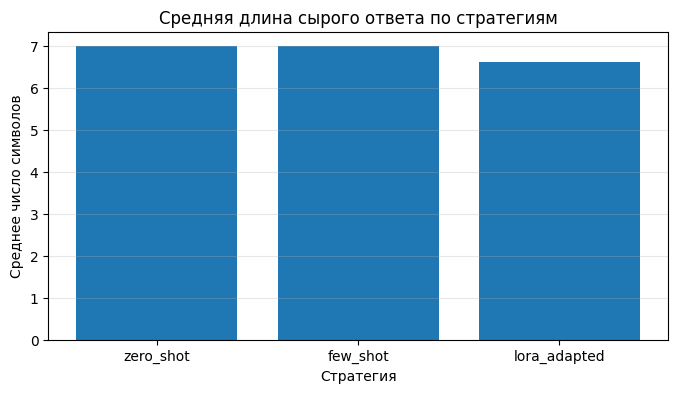

In [26]:
plt.figure(figsize=(8, 4))
plt.bar(format_df["strategy"], format_df["avg_raw_answer_len"])
plt.title("Средняя длина сырого ответа по стратегиям")
plt.xlabel("Стратегия")
plt.ylabel("Среднее число символов")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 14. Разбор ошибок по типам кейсов

Теперь выводим проблемные примеры и пытаемся понять,
какой именно механизм ошибки сработал:

- **неоднозначность формулировки**;
- **смешение близких классов** (`bug` vs `question`);
- **нехватка доменных примеров**;
- **нестабильный формат ответа**.


In [27]:
error_view_cols = ["text", "target_label", "pred_zero", "pred_few"]
if lora_model is not None:
    error_view_cols.append("pred_lora")

errors_df = merged_df.copy()

if lora_model is not None:
    errors_df = errors_df[(~errors_df["ok_zero"]) | (~errors_df["ok_few"]) | (~errors_df["ok_lora"])]
else:
    errors_df = errors_df[(~errors_df["ok_zero"]) | (~errors_df["ok_few"])]

print("Всего проблемных кейсов:", len(errors_df))
display(errors_df[error_view_cols].head(30))


Всего проблемных кейсов: 6


,text,target_label,pred_zero,pred_few,pred_lora
0,Иногда страница аналитики открывается белым экраном.,bug,feature,feature,question
1,Можно ли подключить вход через корпоративный SSO?,question,feature,feature,question
2,Есть ли ограничение на количество пользователей в одной группе?,question,feature,feature,question
4,"Хорошее решение, теперь намного проще объяснять систему новым сотрудникам.",praise,feature,feature,praise
6,В мобильной версии карточка заказа иногда дублируется два раза.,bug,feature,feature,bug
7,"Очень понравилось, что поиск стал находить нужные записи с первого раза.",praise,feature,feature,praise


In [28]:
print("Zero-shot classification report:")
print(classification_report(
    zero_df["target_label"].tolist(),
    [pred if pred is not None else "UNPARSED" for pred in zero_df["predicted_label"]],
    labels=ALLOWED_LABELS,
    zero_division=0,
))

print("\nFew-shot classification report:")
print(classification_report(
    few_df["target_label"].tolist(),
    [pred if pred is not None else "UNPARSED" for pred in few_df["predicted_label"]],
    labels=ALLOWED_LABELS,
    zero_division=0,
))

if lora_model is not None:
    print("\nLoRA-adapted classification report:")
    print(classification_report(
        lora_df["target_label"].tolist(),
        [pred if pred is not None else "UNPARSED" for pred in lora_df["predicted_label"]],
        labels=ALLOWED_LABELS,
        zero_division=0,
    ))


Zero-shot classification report:
              precision    recall  f1-score   support

         bug       0.00      0.00      0.00         2
     feature       0.25      1.00      0.40         2
    question       0.00      0.00      0.00         2
      praise       0.00      0.00      0.00         2

    accuracy                           0.25         8
   macro avg       0.06      0.25      0.10         8
weighted avg       0.06      0.25      0.10         8


Few-shot classification report:
              precision    recall  f1-score   support

         bug       0.00      0.00      0.00         2
     feature       0.25      1.00      0.40         2
    question       0.00      0.00      0.00         2
      praise       0.00      0.00      0.00         2

    accuracy                           0.25         8
   macro avg       0.06      0.25      0.10         8
weighted avg       0.06      0.25      0.10         8


LoRA-adapted classification report:
              precision    

## 15. Итоги

Что важно вынести из этого сравнения:

1. **zero-shot** – самый дешёвый вход в задачу, хорош как быстрый baseline;
2. **few-shot** – часто даёт заметное улучшение без обучения и особенно полезен для пилота;
3. **LoRA-адаптация** – оправдана, когда:
   - домен стабилен;
   - есть размеченные данные;
   - prompt-only даёт нестабильные или недостаточно точные ответы;
   - нужен более предсказуемый формат ответа.

При этом LoRA – не «магическая кнопка».  
Если датасет слишком маленький, классы плохо определены или сами тексты неоднозначны,
то даже адаптированная модель не уберёт все ошибки.

Правильный инженерный вывод обычно такой:

- сначала проверить **zero-shot**;
- затем попробовать **few-shot**;
- и только потом переходить к **PEFT / LoRA**, если выигрыш действительно нужен и оправдан.


## Задания для самостоятельной работы

1. Увеличьте число few-shot примеров с 1 до 2 на каждый класс и сравните результат.
2. Попробуйте другой prompt-шаблон и проверьте, меняется ли `parse_rate`.
3. Измените набор классов, например объедините `praise` и `feature` в один класс «positive / suggestion», и посмотрите, как изменятся ошибки.
4. Добавьте новые доменные тексты, в которых одновременно есть вопрос и описание проблемы, и проверьте устойчивость всех трёх подходов.
5. Сохраните итоговую таблицу сравнения в CSV и кратко сформулируйте вывод:  
   когда в вашей задаче достаточно prompt engineering, а когда уже стоит переходить к адаптации модели.
